### Imports

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torchvision import utils
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### Create model

In [14]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Flatten()                     
        self.hidden_layer1 = nn.Sequential(                
            nn.Linear(in_features=28*28, out_features=512),
            nn.ReLU()
        )
        self.hidden_layer2 = nn.Sequential(
            nn.Linear(in_features=512, out_features=512),
            nn.ReLU()
        )
        self.output_layer = nn.Linear(in_features=512, out_features=10)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.hidden_layer1(x)
        x = self.hidden_layer2(x)
        logits = self.output_layer(x)
        return logits
    
model = NeuralNetwork()
print(model)

NeuralNetwork(
  (input_layer): Flatten(start_dim=1, end_dim=-1)
  (hidden_layer1): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
  )
  (hidden_layer2): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
  )
  (output_layer): Linear(in_features=512, out_features=10, bias=True)
)


### Create dataset & dataloader

Shape of image [N, C, H, W]: torch.Size([1, 1, 28, 28]); dtype = torch.float32
Shape of label: torch.Size([1]); dtype = torch.int64


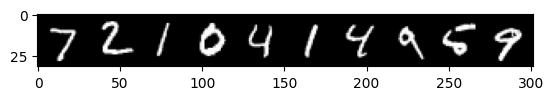

In [15]:
test_data = datasets.MNIST(
    root="./data",
    train=False,
    transform=ToTensor(),
    download=True
)

test_dataloader = DataLoader(
    test_data,
    batch_size=1,
    shuffle=False,
    num_workers=4
)

for images, labels in test_dataloader:
    print(f"Shape of image [N, C, H, W]: {images.shape}; dtype = {images.dtype}")
    print(f"Shape of label: {labels.shape}; dtype = {labels.dtype}")
    break

# Get the first 10 images in the test dataset
images = [image for image, _ in [test_data[i] for i in range(10)]]
# Create a grid of images
grid = utils.make_grid(images, nrow=10)
grid = grid.permute(1, 2, 0)    # Change the order of dimensions (CxHxW) to (HxWxC)
plt.imshow(grid)
plt.show()

In [16]:
def fgsm(image, epsilon, image_grad):
    # element-wise sign of image gradient
    sign_image_grad = image_grad.sign()
    perturbed_image = image + epsilon * sign_image_grad
    
    # clipping to maintain [0,1] range
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image

In [17]:
def test(dataloader, model, device, epsilon, loss_function=nn.CrossEntropyLoss()):
    correct = 0
    adv_examples = []

    for image, label in dataloader:
        image, label = image.to(device), label.to(device)

        # set requires grad attribute of tensor
        image.requires_grad = True

        ## Forward pass
        # Get output
        output = model(image)
        # get the index of the max softmax-probability
        init_pred = output.argmax(dim=1) 

        # If the initial prediction is wrong, don't bother attacking, just move on
        if init_pred.item() != label.item():
            continue

        # Calculate the loss
        loss = loss_function(output, label)

        ## Backward pass
        # zero all existing gradients
        model.zero_grad()

        loss.backward()

        image_grad = image.grad.data

        perturbed_image = fgsm(image, epsilon, image_grad)

        output = model(perturbed_image)

        # Check for success
        final_pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability
        if final_pred.item() == label.item():
            correct += 1
            # Special case for saving 0 epsilon examples
            if epsilon == 0 and len(adv_examples) < 5:
                adv_ex = perturbed_image.squeeze().detach().cpu().numpy()
                adv_examples.append( (init_pred.item(), final_pred.item(), adv_ex) )
        else:
            # Save some adv examples for visualization later
            if len(adv_examples) < 5:
                adv_ex = perturbed_image.squeeze().detach().cpu().numpy()
                adv_examples.append( (init_pred.item(), final_pred.item(), adv_ex) )

    # Calculate final accuracy for this epsilon
    final_acc = correct/float(len(dataloader))
    print(f"Epsilon: {epsilon}\tTest Accuracy = {correct} / {len(dataloader)} = {final_acc}")

    # Return the accuracy and an adversarial example
    return final_acc, adv_examples

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
model = NeuralNetwork().to(device)

# Set this to a checkpoint path to choose manually, or leave it as None to use the newest checkpoint.
checkpoint_to_load = None
# checkpoint_to_load = "checkpoints/model_2026_04_27_14_30_00_e_4"

checkpoints = sorted(Path("checkpoints").glob("model_*"), key=lambda path: path.stat().st_mtime)
if checkpoint_to_load is None:
    if not checkpoints:
        raise FileNotFoundError("No checkpoint found. Run the training cell in mnist_classification.ipynb first.")
    checkpoint_path = checkpoints[-1]
else:
    checkpoint_path = Path(checkpoint_to_load)
    if not checkpoint_path.exists():
        available = "\n".join(str(path) for path in checkpoints)
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}\nAvailable checkpoints:\n{available}")

print(f"Loading checkpoint: {checkpoint_path}")
model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
model.eval()


Device: cpu
Loading checkpoint: checkpoints\model_2026_04_27_14_33_12_e_2


NeuralNetwork(
  (input_layer): Flatten(start_dim=1, end_dim=-1)
  (hidden_layer1): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
  )
  (hidden_layer2): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
  )
  (output_layer): Linear(in_features=512, out_features=10, bias=True)
)

In [19]:
# Set random seed for reproducibility
torch.manual_seed(42)

epsilons = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
accuracies = []
examples = []

# Run test for each epsilon
for eps in epsilons:
    acc, ex = test(test_dataloader, model, device, eps)
    accuracies.append(acc)
    examples.append(ex)

Epsilon: 0	Test Accuracy = 9778 / 10000 = 0.9778
Epsilon: 0.05	Test Accuracy = 7365 / 10000 = 0.7365
Epsilon: 0.1	Test Accuracy = 2708 / 10000 = 0.2708
Epsilon: 0.15	Test Accuracy = 833 / 10000 = 0.0833
Epsilon: 0.2	Test Accuracy = 298 / 10000 = 0.0298
Epsilon: 0.25	Test Accuracy = 113 / 10000 = 0.0113
Epsilon: 0.3	Test Accuracy = 40 / 10000 = 0.004


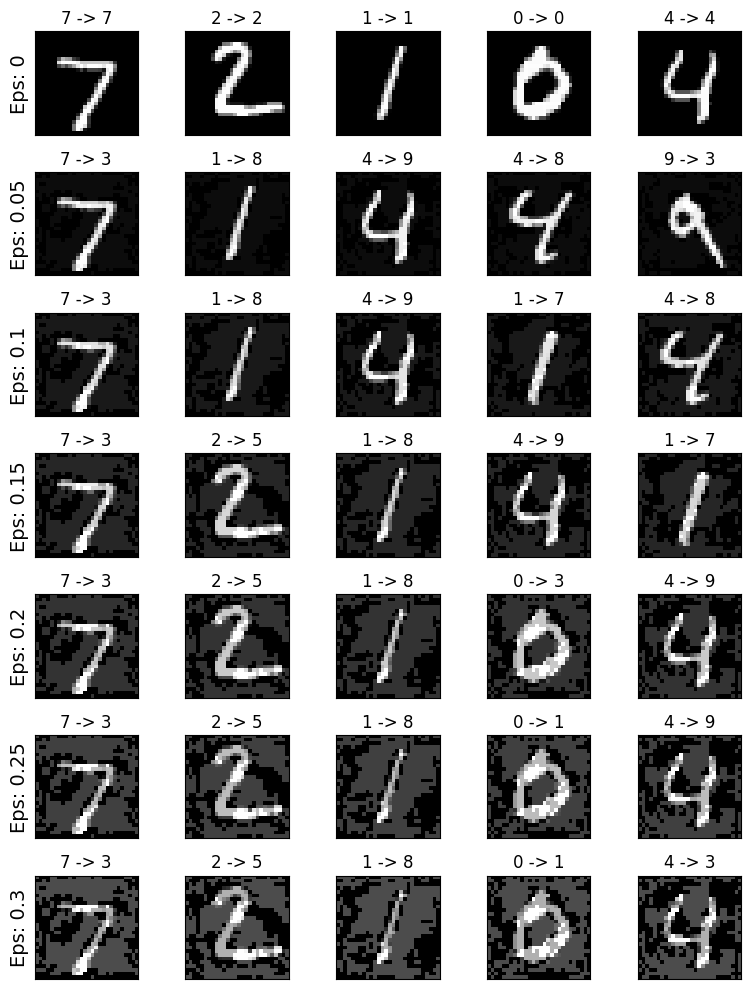

In [21]:
# Plot several examples of adversarial samples at each epsilon
cnt = 0
plt.figure(figsize=(8,10))
for i in range(len(epsilons)):
    for j in range(len(examples[i])):
        cnt += 1
        plt.subplot(len(epsilons),len(examples[0]),cnt)
        plt.xticks([], [])
        plt.yticks([], [])
        if j == 0:
            plt.ylabel(f"Eps: {epsilons[i]}", fontsize=14)
        orig,adv,ex = examples[i][j]
        plt.title(f"{orig} -> {adv}")
        plt.imshow(ex, cmap="gray")
plt.tight_layout()
plt.show()